# 12 — Production Data Pipelines (hands-on)

**Indexed corpus + O(1) bit-exact resume**, on a tiny corpus you build here.

Module 11's streaming data pipeline can't checkpoint its position, so a crashed run
*replays* from sample 0. This notebook builds the production fix on a small scale and
**proves** the two properties that matter:

1. **O(1) random access** — read any sample in constant time from a memory-mapped corpus.
2. **O(1) bit-exact resume** — checkpoint the data position into one integer, crash, and
   resume seeing *exactly* the samples the uninterrupted run would have, in the same order.

Everything runs on CPU, no network. See [README.md](README.md) for the full discussion.

## 0. Build a tiny indexed corpus

We tokenize "once" (here, generate random documents) into the three-file binary format:
`.bin` (flat token stream), `.idx.npy` (per-document sizes), `.meta.json` (header).
The element dtype is the **smallest unsigned int that holds the vocab** — `uint16` for our
small vocab, but `uint32` for a real Qwen3 corpus (vocab 151,936 > 65,535), which is why
`sample-10BT` is ~40 GB on disk, not ~20 GB.

In [1]:
import sys, json, shutil, timeit
from pathlib import Path
import numpy as np
import torch

# Importable when the notebook runs from the module directory.
sys.path.insert(0, str(Path.cwd()))
import indexed_dataset as ix
from indexed_data import (PackedIndexedDataset, ResumableDistributedSampler,
                          make_indexed_dataloader, cycle)

WORK = Path("results/_nb")
if WORK.exists():
    shutil.rmtree(WORK)
WORK.mkdir(parents=True)
PREFIX = str(WORK / "tiny")

VOCAB = 512
EOS = VOCAB - 1
dtype = ix.best_dtype_for_vocab(VOCAB)
print(f"vocab={VOCAB}  ->  dtype={dtype} ({dtype.itemsize} bytes/token)")
print(f"(a Qwen3 corpus, vocab 151,936, would need {ix.best_dtype_for_vocab(151936)})")

builder = ix.IndexedDatasetBuilder(PREFIX, dtype=dtype)
rng = np.random.default_rng(0)
for _ in range(3000):                       # 3000 "documents"
    n = int(rng.integers(40, 250))
    ids = rng.integers(0, VOCAB - 1, size=n).tolist() + [EOS]   # EOS = doc separator
    builder.add_document(ids)
meta = builder.finalize(vocab_size=VOCAB, eos_id=EOS, extra={"source": "synthetic"})
print("\nmeta.json:", json.dumps(meta, indent=2))

vocab=512  ->  dtype=uint16 (2 bytes/token)
(a Qwen3 corpus, vocab 151,936, would need uint32)

meta.json: {
  "dtype": "uint16",
  "total_tokens": 436205,
  "n_docs": 3000,
  "vocab_size": 512,
  "eos_id": 511,
  "source": "synthetic"
}


## 1. The corpus on disk

Three small files. The `.bin` holds every token back-to-back; `.idx.npy` is just the token
count of each document (cumulative-summed, that gives every document's offset); `.meta.json`
is a handful of fields. Megatron packs all of this into one binary blob — we split it so you
can read it with your eyes.

In [2]:
for p in sorted(WORK.glob("tiny*")):
    print(f"  {p.name:20s} {p.stat().st_size:>10,} bytes")

corpus = ix.IndexedDataset(PREFIX)
print(f"\nreopened corpus: {len(corpus):,} docs, {corpus.total_tokens:,} tokens, dtype={corpus.dtype}")

# O(1) per-document access (the Megatron MMapIndexedDataset API).
doc0, docL = corpus[0], corpus[len(corpus) - 1]
print(f"doc 0:    {doc0.size} tokens, first few = {doc0[:6].tolist()}")
print(f"last doc: {docL.size} tokens, ends with EOS({EOS})? {int(docL[-1]) == EOS}")

  tiny.bin                872,410 bytes
  tiny.idx.npy             24,128 bytes
  tiny.meta.json              130 bytes

reopened corpus: 3,000 docs, 436,205 tokens, dtype=uint16
doc 0:    219 tokens, first few = [325, 261, 137, 157, 20, 38]
last doc: 83 tokens, ends with EOS(511)? True


## 2. O(1) random access

Training doesn't use document boundaries — it slices fixed `(seq_len+1)`-token windows out of
the flat stream (the same packing as Module 11). Sample `i` is `flat[i*bl:(i+1)*bl]`, so
reading the *last* sample costs the same as reading the *first*. We time it to show the line
is flat: access time does **not** grow with the index. That constant-time-anywhere property is
the prerequisite for fast resume.

In [3]:
SEQ_LEN = 31                       # block_len = 32
ds = PackedIndexedDataset(corpus, seq_len=SEQ_LEN)
print(f"{len(ds):,} packed training samples of length {SEQ_LEN}")

s = ds[5]
print("sample shapes:", tuple(s["input_ids"].shape), tuple(s["labels"].shape))
assert torch.equal(s["input_ids"][1:], s["labels"][:-1])      # labels[t] == input_ids[t+1]
print("label shift OK (labels are input_ids shifted by +1)")

# Time access at indices spread across the whole corpus.
idxs = np.linspace(0, len(ds) - 1, 12).astype(int)
for i in idxs:                                                 # warm the pages first
    _ = ds[int(i)]
times_us = [timeit.timeit(lambda: ds[int(i)], number=3000) / 3000 * 1e6 for i in idxs]
for i, t in zip(idxs, times_us):
    print(f"  sample {i:6d}: {t:6.2f} us")

13,631 packed training samples of length 31
sample shapes: (31,) (31,)
label shift OK (labels are input_ids shifted by +1)


  sample      0:   4.28 us
  sample   1239:   3.74 us
  sample   2478:   4.44 us
  sample   3717:   4.15 us
  sample   4956:   3.88 us
  sample   6195:   3.47 us
  sample   7434:   3.45 us
  sample   8673:   3.46 us
  sample   9912:   3.74 us
  sample  11151:   3.69 us
  sample  12390:   3.66 us
  sample  13630:   3.74 us


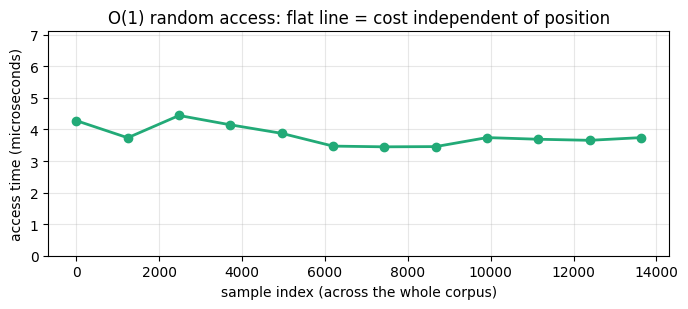

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(idxs, times_us, "o-", color="#2a7", lw=2)
ax.set_ylim(0, max(times_us) * 1.6)
ax.set_xlabel("sample index (across the whole corpus)")
ax.set_ylabel("access time (microseconds)")
ax.set_title("O(1) random access: flat line = cost independent of position")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The shuffle is an explicit permutation

With random access we shuffle the **whole** corpus (not just a sliding buffer): visit samples
in the order of a permutation of `[0, num_samples)`, derived deterministically from
`(seed, epoch)`. Determinism is what makes resume reproducible; the per-epoch reseed means each
pass sees a fresh order.

In [5]:
smp = ResumableDistributedSampler(num_samples=len(ds), micro_batch=4, seed=0)
p0a = np.asarray(smp._permutation(0))
p0b = np.asarray(ResumableDistributedSampler(num_samples=len(ds), micro_batch=4, seed=0)._permutation(0))
p1  = np.asarray(smp._permutation(1))

print("epoch-0 order, first 10 samples:", p0a[:10].tolist())
print("same (seed,epoch) regenerates the identical order:", np.array_equal(p0a, p0b))
print("epoch 1 reseeds to a different order:            ", not np.array_equal(p0a, p1))
print("it's a true permutation (covers every sample once):", sorted(p0a.tolist()) == list(range(len(ds))))

epoch-0 order, first 10 samples: [3646, 6063, 6691, 1, 12225, 315, 6816, 7505, 9326, 10687]
same (seed,epoch) regenerates the identical order: True
epoch 1 reseeds to a different order:             True
it's a true permutation (covers every sample once): True


## 4. O(1) bit-exact resume — the headline

The **entire** resume state for the data loader is one integer, `consumed_samples`. We:

1. run a sampler uninterrupted and record every batch (the *reference*);
2. run a fresh sampler, take some steps, **checkpoint** (`state_dict()`), throw it away;
3. build a brand-new sampler, **`load_state_dict`**, and continue.

Then we assert the interrupted run visited the **identical** sequence of samples — including
across the epoch boundary, where the permutation reseeds. No replay: resume jumps to the saved
position by arithmetic.

In [6]:
MICRO = 4
active = (len(ds) // MICRO) * MICRO
steps_per_epoch = active // MICRO
N = steps_per_epoch + 8          # run past one epoch boundary
SAVE_AT = steps_per_epoch - 3    # checkpoint just before the boundary

def take(sampler, n):
    out, got = [], 0
    while got < n:
        for batch in iter(sampler):        # one epoch; re-iter advances to next epoch
            out.append(tuple(batch)); got += 1
            if got >= n: break
    return out

def fresh(consumed=0):
    return ResumableDistributedSampler(num_samples=len(ds), micro_batch=MICRO,
                                       seed=123, consumed_samples=consumed)

# (1) uninterrupted reference
reference = take(fresh(), N)

# (2) run SAVE_AT steps, then checkpoint
smp = fresh()
first = take(smp, SAVE_AT)
state = smp.state_dict()
print("data-loader checkpoint:", state)
del smp

# (3) brand-new sampler, load state, continue
smp2 = fresh(consumed=99999)               # deliberately wrong...
smp2.load_state_dict(state)                # ...overwritten by the checkpoint
rest = take(smp2, N - SAVE_AT)

ok = (first + rest) == reference
print(f"\ncheckpoint after {SAVE_AT} steps (epoch {state['consumed_samples']//active}); resumed for {N-SAVE_AT} more")
print("resumed run is BIT-EXACT vs uninterrupted:", ok)
assert ok, "resume diverged!"
print("first batch after resume:", rest[0], " == reference batch", SAVE_AT, ":", reference[SAVE_AT])

data-loader checkpoint: {'consumed_samples': 13616, 'seed': 123, 'num_samples': 13631, 'step_samples': 4}

checkpoint after 3404 steps (epoch 0); resumed for 11 more
resumed run is BIT-EXACT vs uninterrupted: True
first batch after resume: (2316, 5225, 12521, 5753)  == reference batch 3404 : (2316, 5225, 12521, 5753)


**Why this is O(1).** Resuming did not iterate through the `consumed_samples` already seen —
it computed `epoch` and `chunk_to_skip` by integer division and started there. Contrast Module
11, where a fresh stream opens at sample 0 and the model replays everything up to the crash.

## 5. Distributed sharding via the index

With `world_size` ranks, each epoch's permutation is cut into `step_samples = micro_batch x world`
chunks; rank `r` takes the contiguous slice `chunk[r*micro:(r+1)*micro]`. We simulate `world=4`
and confirm the ranks are **disjoint** and together **cover** every usable sample exactly once —
no communication needed, since every rank derives the same permutation from the same seed.

In [7]:
WORLD = 4
steps_per_epoch_w = len(ds) // (MICRO * WORLD)
seen = []
for r in range(WORLD):
    smp = ResumableDistributedSampler(num_samples=len(ds), micro_batch=MICRO,
                                      num_replicas=WORLD, rank=r, seed=7)
    idxs = [i for batch in take(smp, steps_per_epoch_w) for i in batch]
    seen.append(idxs)
    print(f"  rank {r}: {len(idxs)} samples, first batch = {idxs[:MICRO]}")

flat = [i for s in seen for i in s]
active_w = (len(ds) // (MICRO * WORLD)) * (MICRO * WORLD)
perm0 = np.asarray(ResumableDistributedSampler(num_samples=len(ds), micro_batch=MICRO,
                                               num_replicas=WORLD, rank=0, seed=7)._permutation(0))
print("\ndisjoint across ranks: ", len(flat) == len(set(flat)))
print("covers epoch's samples: ", set(flat) == set(perm0[:active_w].tolist()))
print("balanced (equal per rank):", len({len(s) for s in seen}) == 1)

  rank 0: 3404 samples, first batch = [9747, 8289, 5047, 6651]
  rank 1: 3404 samples, first batch = [10556, 5801, 2943, 3084]
  rank 2: 3404 samples, first batch = [9636, 3418, 6714, 4353]
  rank 3: 3404 samples, first batch = [9123, 664, 5796, 6958]

disjoint across ranks:  True
covers epoch's samples:  True
balanced (equal per rank): True


## 6. Recap

| | Streaming (Module 11) | Indexed (this module) |
|---|---|---|
| Resume state | none (hidden iterator) | one integer `consumed_samples` |
| Cost to resume to step N | replay N·tokens, re-tokenizing | O(1) arithmetic + one mmap slice |
| Same data as no-crash run | **no** | **yes — bit-exact** |
| Tokenizer cost | every epoch | once, ever |
| Shuffle | local buffer window | global permutation |

You built a corpus, read it in O(1), shuffled it with a deterministic permutation, and proved a
crashed run resumes bit-for-bit from one saved integer. That's the data pipeline frontier labs run.
Run `python tests/test_indexed_resume.py` for the same properties as a pass/fail check, and see
the README §7 for the three-edit drop-in into Module 11's `train.py`.

In [8]:
shutil.rmtree(WORK, ignore_errors=True)
print("cleaned up", WORK)

cleaned up results/_nb
